Script 3.1: Wavepacket Initialization

In [44]:
import numpy as np
import scipy.linalg as spLA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [45]:
# ─────────────────────────────────────────────
# SCRIPT 3.1 — Wavepacket Initialization
# ─────────────────────────────────────────────
 
def psi0(x, p0, x0):
    """Gaussian wavepacket awal di posisi x0 dengan momentum p0."""
    y = (1/np.pi)**0.25 * np.exp(-0.5*((x - x0)**2) + 1j*p0*x)
    return y
 
# Parameter sistem
N      = 256  # Jumlah titik grid
xmax   =  5.0     # Batas kanan grid posisi
xmin   = -5.0     # Batas kiri grid posisi
x0     =  1.0     # Posisi awal wavepacket
p0     =  0.0     # Momentum awal wavepacket
mass   =  1.0     # Massa partikel
omega  =  1.0     # Frekuensi osilator
hbar   =  1.0     # Konstanta Planck (atomic units)
 
# Grid posisi dan momentum
dx = (xmax - xmin) / N
dp = 2 * np.pi / (xmax - xmin)
 
xv = np.array([(j - N/2) * dx for j in range(N)])          # grid posisi
pv = np.fft.fftfreq(N, d=dx) * 2 * np.pi                   # grid momentum (FFT-ordered)
pv_shift = np.fft.fftshift(pv)                              # grid momentum (diurutkan untuk plot)
 
# State awal
psio = psi0(xv, p0, x0)

Script 3.2: SOFT Operators for Harmonic Oscillator

In [46]:
# ─────────────────────────────────────────────
# SCRIPT 3.2 — SOFT Operators
# ─────────────────────────────────────────────

def harmonic(xgrid, mass, omega):
    """Potensial harmonic oscillator V(x) = 0.5 * m * omega^2 * x^2"""
    pot = 0.5 * mass * (omega**2) * (xgrid**2)
    return pot

# Parameter propagasi
Nsteps     = 800  # Jumlah langkah waktu
total_time = 40  # Total waktu propagasi [a.u.]
tau        = total_time / Nsteps   # Ukuran satu langkah waktu

# Propagator potensial: e^{-i * V(x) * tau/2 / hbar}   [half-step]
V_ho    = harmonic(xv, mass, omega)
V_prop  = np.exp(-1.j / hbar * V_ho * tau / 2.)

# Propagator kinetik: e^{-i * p^2/(2m) * tau / hbar}   [full-step]
KE_ho   = pv**2 / (2. * mass)
KE_prop = np.exp(-1.j / hbar * KE_ho * tau)

In [47]:
# ─────────────────────────────────────────────
# SCRIPT 3.3 — SOFT Propagation (1 time step)
# ─────────────────────────────────────────────

def soft(psi, pot_prop, kin_prop):
    """
    Satu langkah SOFT:
    1. Half-step P.E. propagator  (ruang posisi)
    2. FFT ke ruang momentum
    3. Full-step K.E. propagator  (ruang momentum)
    4. IFFT balik ke ruang posisi
    5. Half-step P.E. propagator  (ruang posisi)
    """
    out = pot_prop * psi                       # ① half-step P.E.
    out = kin_prop * np.fft.fft(out)           # ② FFT  +  ③ full K.E.
    out = pot_prop * np.fft.ifft(out)          # ④ IFFT +  ⑤ half P.E.
    return out

In [48]:
# ─────────────────────────────────────────────
# LOOP PROPAGASI — kumpulkan data
# ─────────────────────────────────────────────

psi = psio.copy()

# Untuk expectation values
xs_soft, ps_soft = [], []

# Untuk snapshot wavepacket (pilih langkah yang ingin ditampilkan)
snapshot_steps = [0, 25, 50, 75, 100, 125, 150, 175, 199]
snaps_pos  = {}   # |ψ(x)|² di tiap snapshot
snaps_mom  = {}   # |ψ̃(p)|² di tiap snapshot

# Simpan snapshot awal (t=0)
psi_k_init = np.fft.fftshift(np.fft.fft(psi)) * dx
snaps_pos[0] = np.abs(psi)**2
snaps_mom[0] = np.abs(psi_k_init)**2 / (2 * np.pi)

# Jalankan loop
for step in range(1, Nsteps):
    psi = soft(psi, V_prop, KE_prop)

    # Expectation value posisi: <x> = integral |ψ(x)|² * x dx
    x_exp = np.real(np.sum(np.conj(psi) * xv * psi) * dx)

    # Expectation value momentum: <p> di ruang momentum
    psi_k = np.fft.fftshift(np.fft.fft(psi)) * dx
    p_exp = np.real(np.sum(np.conj(psi_k) * pv_shift * psi_k)) * dp / (2 * np.pi)

    xs_soft.append(x_exp)
    ps_soft.append(p_exp)

    # Simpan snapshot jika langkah ini termasuk
    if step in snapshot_steps:
        snaps_pos[step] = np.abs(psi)**2
        snaps_mom[step] = np.abs(psi_k)**2 / (2 * np.pi)

times = np.linspace(tau, total_time, Nsteps - 1)

In [49]:
# ─────────────────────────────────────────────
# SOLUSI ANALITIK (untuk validasi)
# ─────────────────────────────────────────────

x_ana = x0 * np.cos(omega * times) + (p0 / (mass * omega)) * np.sin(omega * times)
p_ana = -mass * omega * x0 * np.sin(omega * times) + p0 * np.cos(omega * times)

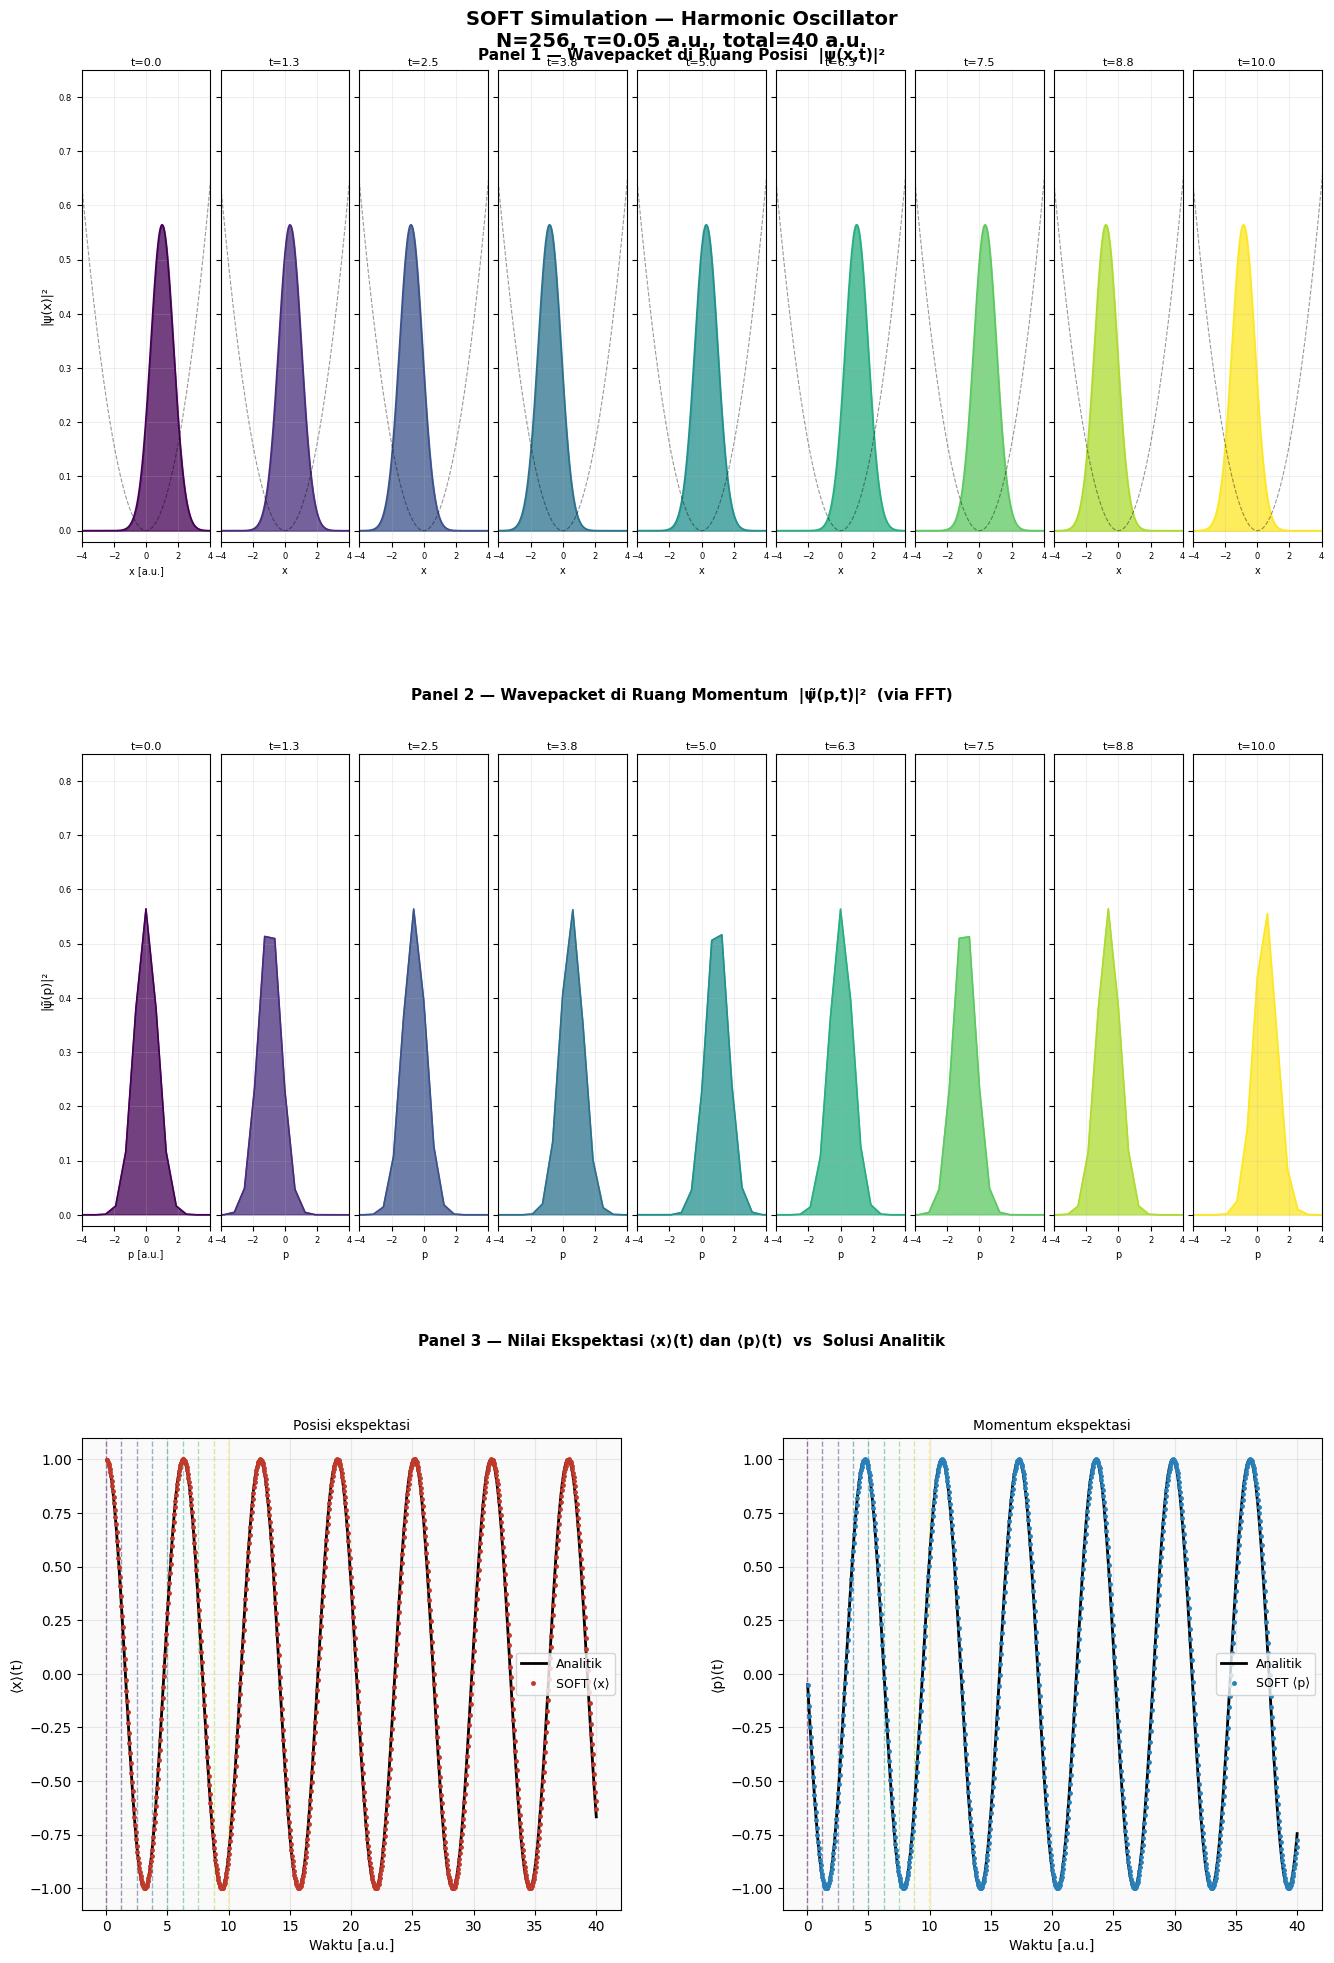

Selesai.


In [50]:
"""
SOFT (Split-Operator Fourier Transform) Simulation
Quantum Dynamics Tutorial — Section 3.1
Harmonic Oscillator dengan visualisasi wavepacket posisi & momentum

Gabungan dari Script 3.1, 3.2, 3.3 di paper + representasi wavepacket
"""
# ─────────────────────────────────────────────
# VISUALISASI — 3 Panel
# ─────────────────────────────────────────────

cmap  = plt.colormaps['viridis']
nsnap = len(snapshot_steps)

fig = plt.figure(figsize=(16, 20), facecolor='white')
fig.suptitle(
    'SOFT Simulation — Harmonic Oscillator\n'
    f'N={N}, τ={tau:.2f} a.u., total={total_time} a.u.',
    fontsize=14, fontweight='bold', y=0.99
)

gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.45, top=0.96, bottom=0.04)

# ── Panel 1: Wavepacket di ruang POSISI ─────────────────────
gs1 = gridspec.GridSpecFromSubplotSpec(1, nsnap, subplot_spec=gs[0], wspace=0.08)
fig.text(0.5, 0.965,
         'Panel 1 — Wavepacket di Ruang Posisi  |ψ(x,t)|²',
         ha='center', fontsize=11, fontweight='bold')

V_scaled = V_ho * 0.08   # skalakan potensial agar muat di plot

for idx, step in enumerate(snapshot_steps):
    ax = fig.add_subplot(gs1[idx])
    t_val = 0.0 if step == 0 else times[step - 1]
    color = cmap(idx / (nsnap - 1))

    ax.fill_between(xv, 0, snaps_pos[step], alpha=0.75, color=color)
    ax.plot(xv, snaps_pos[step], '-', color=color, lw=1.2)
    ax.plot(xv, V_scaled, 'k--', lw=0.8, alpha=0.4, label='V(x) scaled')

    ax.set_xlim(-4, 4)
    ax.set_ylim(-0.02, 0.85)
    ax.set_title(f't={t_val:.1f}', fontsize=8, pad=3)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

    if idx == 0:
        ax.set_ylabel('|ψ(x)|²', fontsize=9)
        ax.set_xlabel('x [a.u.]', fontsize=7)
    else:
        ax.set_yticklabels([])
        ax.set_xlabel('x', fontsize=7)

# ── Panel 2: Wavepacket di ruang MOMENTUM ───────────────────
gs2 = gridspec.GridSpecFromSubplotSpec(1, nsnap, subplot_spec=gs[1], wspace=0.08)
fig.text(0.5, 0.645,
         'Panel 2 — Wavepacket di Ruang Momentum  |ψ̃(p,t)|²  (via FFT)',
         ha='center', fontsize=11, fontweight='bold')

for idx, step in enumerate(snapshot_steps):
    ax = fig.add_subplot(gs2[idx])
    t_val = 0.0 if step == 0 else times[step - 1]
    color = cmap(idx / (nsnap - 1))

    ax.fill_between(pv_shift, 0, snaps_mom[step], alpha=0.75, color=color)
    ax.plot(pv_shift, snaps_mom[step], '-', color=color, lw=1.2)

    ax.set_xlim(-4, 4)
    ax.set_ylim(-0.02, 0.85)
    ax.set_title(f't={t_val:.1f}', fontsize=8, pad=3)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.2)

    if idx == 0:
        ax.set_ylabel('|ψ̃(p)|²', fontsize=9)
        ax.set_xlabel('p [a.u.]', fontsize=7)
    else:
        ax.set_yticklabels([])
        ax.set_xlabel('p', fontsize=7)

# ── Panel 3: Expectation values vs waktu ────────────────────
gs3 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[2], wspace=0.3)
fig.text(0.5, 0.322,
         'Panel 3 — Nilai Ekspektasi ⟨x⟩(t) dan ⟨p⟩(t)  vs  Solusi Analitik',
         ha='center', fontsize=11, fontweight='bold')

ax_x = fig.add_subplot(gs3[0])
ax_p = fig.add_subplot(gs3[1])

# Garis vertikal penanda snapshot
for idx, step in enumerate(snapshot_steps):
    t_val = 0.0 if step == 0 else times[step - 1]
    color = cmap(idx / (nsnap - 1))
    ax_x.axvline(t_val, color=color, alpha=0.5, lw=1.0, ls='--')
    ax_p.axvline(t_val, color=color, alpha=0.5, lw=1.0, ls='--')

ax_x.plot(times, x_ana,    'k-',  lw=2,   label='Analitik')
ax_x.plot(times, xs_soft,  'o',   color='#c0392b', ms=2.5, label='SOFT ⟨x⟩')
ax_x.set_xlabel('Waktu [a.u.]', fontsize=10)
ax_x.set_ylabel('⟨x⟩(t)',       fontsize=10)
ax_x.set_title('Posisi ekspektasi', fontsize=10)
ax_x.legend(fontsize=9)
ax_x.grid(True, alpha=0.25)
ax_x.set_facecolor('#fafafa')

ax_p.plot(times, p_ana,    'k-',  lw=2,   label='Analitik')
ax_p.plot(times, ps_soft,  'o',   color='#2980b9', ms=2.5, label='SOFT ⟨p⟩')
ax_p.set_xlabel('Waktu [a.u.]', fontsize=10)
ax_p.set_ylabel('⟨p⟩(t)',       fontsize=10)
ax_p.set_title('Momentum ekspektasi', fontsize=10)
ax_p.legend(fontsize=9)
ax_p.grid(True, alpha=0.25)
ax_p.set_facecolor('#fafafa')

plt.savefig('soft_wavepacket_full.png', dpi=150, bbox_inches='tight')
plt.show()
print("Selesai.")